# Adversarial Attacks

The goal of an adversarial attack is to create an image by introducing a small perturbation in a legitimate image, correctly classified by a deep learning model, such that the perturbed image is misclassified. While many adversarial attacks aim for changes that are difficult for humans to notice, imperceptibility is not a strict requirement.

In this notebook, we present two methods to craft adversarial samples using deep learning networks: **Fast Gradient Sign Method (FGSM)**, and **Projected Gradient Descent (PGD).**

The goals are to: 

1. Illustrate how simple gradient-based attacks are constructed; 

2. Visualize perturbations and their effects on model predictions; 

3. Qualitatively demonstrate the idea of transferability across different models using a single representative example.

**FGSM paper:**

Explaining and Harnessing Adversarial Examples, Ian J. Goodfellow, Jonathon Shlens, Christian Szegedy - https://arxiv.org/abs/1412.6572

**PGD paper:**

Towards Deep Learning Models Resistant to Adversarial Attacks, Aleksander Madry, Aleksandar Makelov, Ludwig Schmidt - https://arxiv.org/pdf/1706.06083



## Preparation

In [2]:
import torch
import torchvision
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import numpy as np
import time

from PIL import Image

# importing a module with utilities for displaying stats and data
import sys


### Model definition

In [3]:
class Conv(torch.nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(3, 16, 3)
        self.bn1 = torch.nn.BatchNorm2d(16)
        self.relu1 = torch.nn.ReLU()

        self.conv2 = torch.nn.Conv2d(16, 32, 3)
        self.bn2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()

        self.maxpool1 = torch.nn.MaxPool2d(2)


        self.conv3 = torch.nn.Conv2d(32, 48, 3)
        self.bn3 = torch.nn.BatchNorm2d(48)
        self.relu3 = torch.nn.ReLU()

        self.conv4 = torch.nn.Conv2d(48, 48, 3)
        self.bn4 = torch.nn.BatchNorm2d(48)
        self.relu4 = torch.nn.ReLU()

        self.maxpool2 = torch.nn.MaxPool2d(2)

        self.fc1 = torch.nn.Linear(1200, num_classes)
        

    def forward(self, x):    
        
        # input = (bs, 3, 32, 32)
        x = self.conv1(x) # -> (bs, 16, 30, 30)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x) # -> (bs, 32, 28, 28)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.maxpool1(x) # -> (bs, 32, 14, 14)
        
        x = self.conv3(x) # -> (bs, 48, 12, 12)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.conv4(x) # -> (bs, 48, 10, 10)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.maxpool2(x) # -> (bs, 48, 5, 5)
        
        x = torch.flatten(x,1) # -> (bs, 48 * 5 * 5 = 1200)
        x = self.fc1(x)        # -> (bs, num_classes)

        return(x)
    

def plot_predictions(img, models, correct):

    fig, axes = plt.subplots(nrows=1, ncols=len(models), sharey=True, figsize = (20, 2))

    for i, ax in enumerate(axes.ravel()):

        output = models[i].forward(img)
        output_probs = torch.nn.functional.softmax(output, dim=-1).cpu().detach().numpy().squeeze(0)
        pred = np.argmax(output_probs, axis=-1)
        num_classes = output_probs.shape[-1]
        colors = ["#777777" for i in range(num_classes)]
        colors[pred] = 'red'
        colors[correct] = 'blue'
        ax.set_title(f'Model {i}')
        ax.bar(range(8), output_probs, color=colors)
        ax.set_ylim([0, 1])
        ax.set_xticks(range(8))


def plot_adversarial(original, perturbation, adversarial):

    fig, axes = plt.subplots(nrows=1, ncols=3, sharey=True, figsize = (6,2))

    ax = axes.ravel()

    ax[0].set_title(f'Original')
    ax[0].imshow(np.transpose(original.cpu().detach().numpy().squeeze(0), (1,2,0))) 
    ax[0].axis('off')     

    ax[1].set_title(f'Perturbation')
    ax[1].imshow(np.transpose(perturbation.cpu().detach().numpy().squeeze(0), (1,2,0))) 
    ax[1].axis('off')   

    ax[2].set_title(f'Adversarial')
    ax[2].imshow(np.transpose(adversarial.cpu().detach().numpy().squeeze(0), (1,2,0))) 
    ax[2].axis('off')           

In [4]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


## Models and reference image

We start by loading a small ensemble of convolutional networks that were trained on a subset of the GTSRB traffic sign dataset in previous notebooks. Each model has the same architecture but was trained independently, with different random seeds and data augmentations. One of these models will serve as a source for crafting adversarial examples, while the rest will be used for testing transferability.

In [5]:

models = []
acc = []

for i in range(10):

    reload = torch.load(f'models_augmented/aug_II_{i}_best.pt')
    model = Conv(8)
    model.load_state_dict(reload['model'])
    model.to(device)
    models.append(model)
    

C:\Users\anton\AppData\Local\Temp\ipykernel_31904\1376551405.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  reload = torch.load(f'models_augmented/aug_II_{i}_best.pt')


In [6]:
PATH_TEST_SET = 'data/gtsrb/test_A'

transform = v2.Compose(
    [v2.Resize((32,32)), 
     v2.ToImage(), 
     v2.ToDtype(torch.float32, scale=True)]) 

# No shuffle is required for the test set, also the batch size can be completely different
test_set = torchvision.datasets.ImageFolder(root=PATH_TEST_SET, transform = transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size = 128)

### Prepare an image

### Reference image

For the experiments below we will use a single test image that all 10 models classify correctly. Using a common, correctly classified reference image lets us focus on how different attacks change the predictions and on how adversarial examples transfer between models.

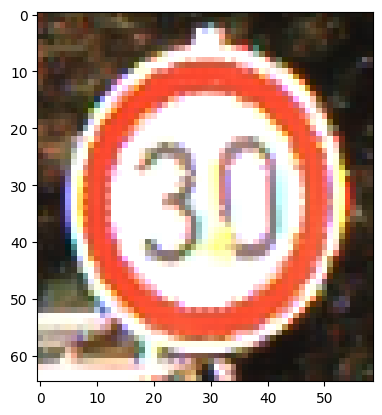

In [7]:
img = Image.open('data/gtsrb/test_A/00001/s00024.png')
class_id = 1

plt.imshow(img)



### Feed the image in all models 

We now pass the selected test image through each of the 10 models and verify that they all predict the same, correct class. This sanity check ensures that the image is a clean reference point and that any changes in predictions later are due to the adversarial perturbations, which is important for interpreting transferability.

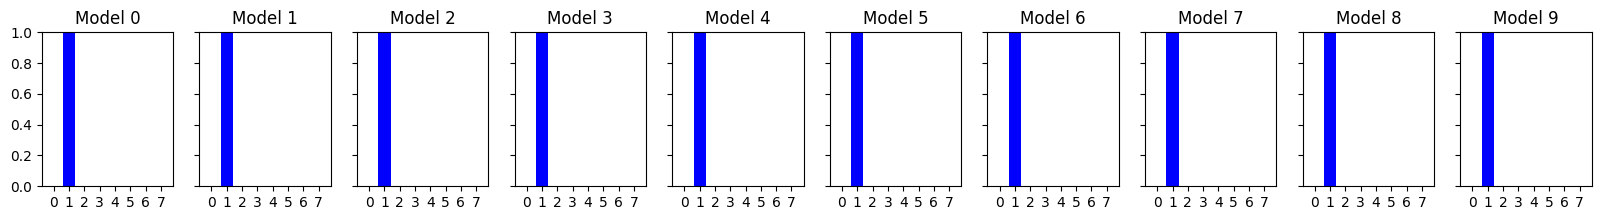

In [8]:
img_tensor = transform(img).unsqueeze(0).to(device)
plot_predictions(img_tensor, models, class_id)

### Norms and $L^p$ balls

When defining adversarial perturbations, we usually restrict how much we are allowed to change the image by requiring the perturbation $\delta$ to lie inside an $L^p$ **ball** around the original image $x$. For a given radius $epsilon > 0$, the $L^p$ ball is the set of all perturbations whose $L^p$ norm is at most $\epsilon$.

Two cases are especially common in adversarial attacks:

- **$L^\infty$ ball:** $\|\delta\|_{\infty} \le \epsilon \Longleftrightarrow |\delta_i| \le \epsilon$ for every pixel . This means that the absolute change of *each* pixel is at most $\epsilon$; no individual pixel is perturbed more than $\epsilon$. This is the constraint used by FGSM and the standard PGD attack in many works.
- **$L^2$ ball:** $\|\delta\|_{2} \le \epsilon$. Here the **overall** Euclidean magnitude of the perturbation is bounded by $\epsilon$, without directly limiting each pixel separately.

In practice, we construct an adversarial example as $x_{\text{adv}} = x + \delta$ and enforce the norm constraint by projecting $\delta$ back into the appropriate $L^p$ ball after each update step.

## FGSM

Introduced in 2014, the Fast Gradient Sign Method (FGSM) showed that the same gradients used in training a neural network can also be used to construct adversarial images. In regular training we compute the gradient of the loss with respect to the weights and update the weights by backpropagation. In contrast, FGSM computes the gradient of the loss with respect to the input image itself and uses that gradient to update the image.

FGSM generates a perturbation in a single step. Let $\theta$ represent the model parameters, $x$ the input image, $y$ its true class, and $L(\theta, x, y)$ the loss function. The FGSM perturbation is:

$$\eta = \epsilon \cdot \text{sign}(\nabla_x(L(\theta, x, y)))$$

The adversarial image is then:

$$z = x + \eta $$

In other words, we compute the gradient of the loss with respect to the input image, take its sign, scale it by the small constant $\epsilon$, and add this perturbation $\eta$ to the original image. If the resulting image is misclassified by the model, it is called an adversarial example.


### Feed the image to the first model and compute the gradients relatively to the input

The function below computes the perturbation

In [9]:
loss_fn = torch.nn.CrossEntropyLoss()

def compute_FGSM_perturbation(image, label, model, epsilon):

    image.requires_grad = True
    if image.grad is not None:
        image.grad.zero_()
    output = model(image)
    loss = loss_fn(output, label)
    model.zero_grad()
    loss.backward()
    perturbation = epsilon * image.grad.data.sign()

    return perturbation


Create the adversarial image

In [10]:
epsilon = 0.05

perturbation = compute_FGSM_perturbation(img_tensor, torch.tensor([class_id]).to(device), models[0], epsilon)

adversarial = img_tensor + perturbation

### Check if the adversarial is misclassified

In [11]:
output = models[0](adversarial)
out_probs = torch.nn.functional.softmax(output[0], -1)
print(out_probs.cpu().detach().numpy())
print('Class after perturbation: ', np.argmax(out_probs.cpu().detach().numpy()))

[2.3909070e-09 3.5121695e-06 1.9142797e-06 3.4441706e-07 4.8486104e-10
 9.9999428e-01 1.2442580e-09 6.9537474e-09]
Class after perturbation:  5


### Show the images

Original image , perturbation, adversarial image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.05..0.05].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.004901964..1.05].


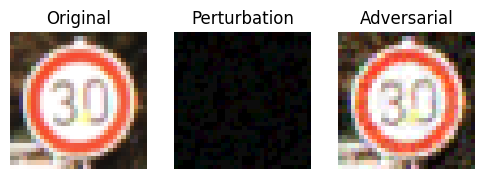

In [12]:
plot_adversarial(img_tensor, perturbation, adversarial)

### Transferability of adversarial examples

An important property of adversarial examples is **transferability**: a perturbation crafted to fool one source model can sometimes also fool other models trained on the same task, even if they were trained independently. In other cases, different models respond differently to the same adversarial input, and some may still classify it correctly.

In this notebook we take a simple, illustrative approach: we generate one adversarial example for a chosen model, then feed exactly the same perturbed image to the remaining models in our ensemble and inspect their predictions.

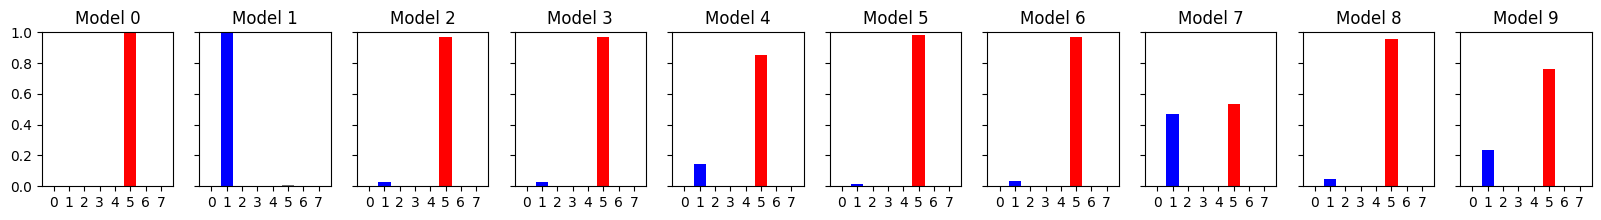

In [13]:
plot_predictions(adversarial, models, class_id)

### Valid pixel range and clamping

Note that the adversarial output of the attack may be an **invalid image**, because some pixel values can fall outside the range \([0, 1]\).We therefore clamp the adversarial tensor to \([0, 1]\) to obtain a valid image before using it for visualization and transferability evaluation.

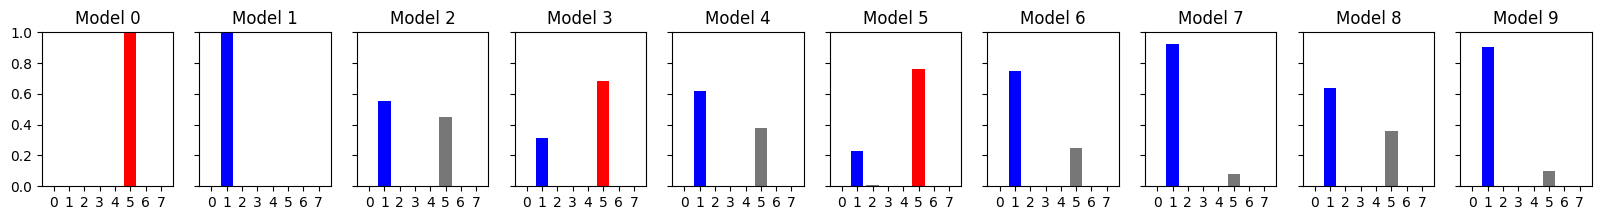

In [14]:
adversarial_clamped = adversarial.clamp(0,1)

plot_predictions(adversarial_clamped, models, class_id)

These results show that the adversarial example reliably fools the model it was crafted for, but only a minority of the remaining models misclassify it. In other words, transferability is present but not guaranteed: some models remain correct on this particular adversarial image, even though they were trained on the same task.

Printing the classes predicted by each model

In [15]:
outputs = []

for i in range(0,10):

    output = models[i](adversarial_clamped)
    out_probs = torch.nn.functional.softmax(output[0], -1)
    outputs.append(np.argmax(out_probs.cpu().detach().numpy()))

print(outputs)

[5, 1, 1, 5, 1, 5, 1, 1, 1, 1]


### Effect of $\epsilon$ on the perturbation

The parameter $\epsilon$ controls the maximum change applied to each pixel in the FGSM perturbation. Small values of $\epsilon$ produce subtle perturbations that may or may not be visible, while larger values make the perturbation and the resulting adversarial image increasingly noticeable.

Below we fix the target class and vary $\epsilon$, plotting the original image, the perturbation, and the adversarial image for each value to visualize this trade‑off.

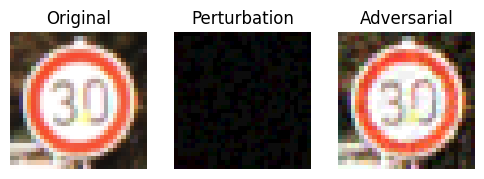

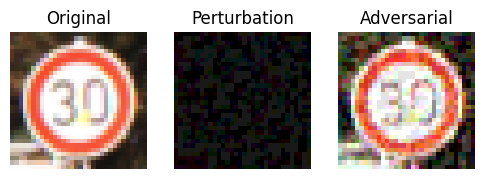

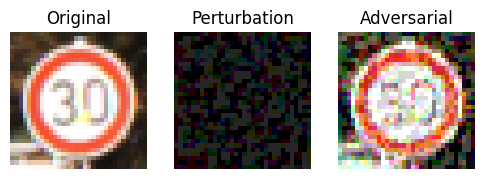

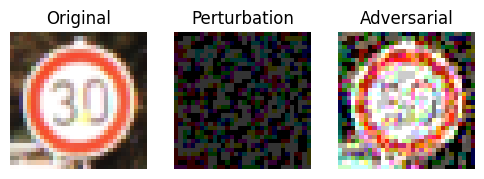

In [16]:
target_label = 2


for epsilon in [0.05, 0.10, 0.15, 0.20]:
    tensor_label = torch.tensor([target_label], device=device)
    perturbation = compute_FGSM_perturbation(img_tensor, tensor_label, models[0], epsilon)
    adversarial = (img_tensor - perturbation).clamp(0, 1)
    plot_adversarial(img_tensor, perturbation.clamp(0, 1), adversarial)

## Targeted attack

The original FGSM was designed to craft adversarial examples by creating perturbations that cause images to be misclassified, without controlling which incorrect class the model predicts. This is known as a **non-targeted attack**.

However, the same approach can be easily adapted to create adversarial examples that are not just misclassified, but get classified in a specific (incorrect) class chosen by the attacker. This variant is known as **targeted attacks**.

To perform a targeted attack on an original image $x$, the attacker picks a class, and the loss function is computed as if that class were correct. The perturbation $\eta$ is computed as in FGSM, but we subtract it from the input to decrease the loss of the target class:

$$z = x - \eta $$

This sign flip (minus instead of plus) is what distinguishes targeted FGSM from the non‑targeted version, where we add the perturbation to increase the loss of the true class.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1..0.1].


[[-15.750348   -8.19872    10.014948   -7.4200726 -11.213524   -6.570371
  -15.3614     -8.55827  ]] 2


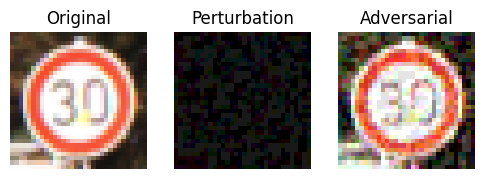

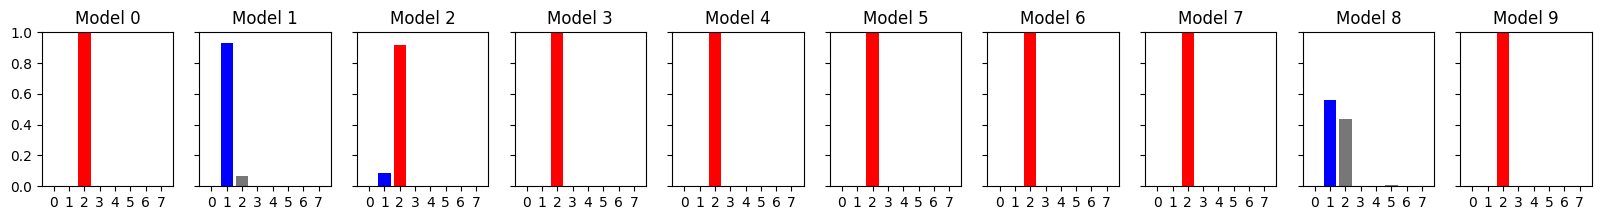

In [17]:
#note: epsilon has to be set higher than in the non-targeted attack
epsilon = 0.1
target_class = 2

perturbation = compute_FGSM_perturbation(img_tensor, 
                                         torch.tensor([target_class]).to(device), 
                                         models[0], 
                                         epsilon )

adversarial = (img_tensor - perturbation).clamp(0,1)


plot_adversarial(img_tensor, perturbation, adversarial)
output = models[0](adversarial).cpu().detach().numpy()
print(output, np.argmax(output))

plot_predictions(adversarial.clamp(0,1), models, 1)

## Iterative FGSM


FGSM takes a **single** step in the direction of the gradient sign to construct an adversarial example. A straightforward way to make the attack stronger is to apply several **smaller** FGSM-like steps instead of one large step, updating the image a little at a time. This idea leads to the **iterative FGSM** (often called the basic iterative method).

In the iterative version, we start from the original image and, at each iteration, compute the gradient of the loss with respect to the current adversarial image, take its sign, and move by a small step size $\alpha$. After each update we project the result back into the allowed L∞ ball of radius $\epsilon$ around the original image and clamp it to the valid pixel range $[0, 1]$. For a targeted attack we subtract this signed gradient step (to decrease the loss of the target class), while for an untargeted attack we add it (to increase the loss of the true class).

In [18]:
def compute_I_FGSM_adversarial(image, label, targeted, model, iterations, epsilon, alpha):

    original_image = image.detach()
    adversarial = original_image.clone().detach()

    for i in range(iterations):

        adversarial.requires_grad = True
        output = model(adversarial)
        loss = loss_fn(output, label)
        model.zero_grad()
        loss.backward()

        # compute perturbation
        perturbation = alpha * adversarial.grad.data.sign()
        
        # update adversarial
        if targeted:
            adversarial = adversarial - perturbation
        else:
            adversarial = adversarial + perturbation

        # clamp update relative to the original image
        delta = torch.clamp(adversarial - original_image, -epsilon, +epsilon)
        adversarial = torch.clamp(original_image + delta, min=0, max=1).detach()

    return adversarial, delta
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1..0.1].


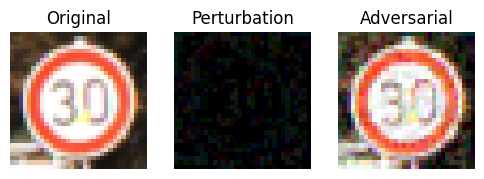

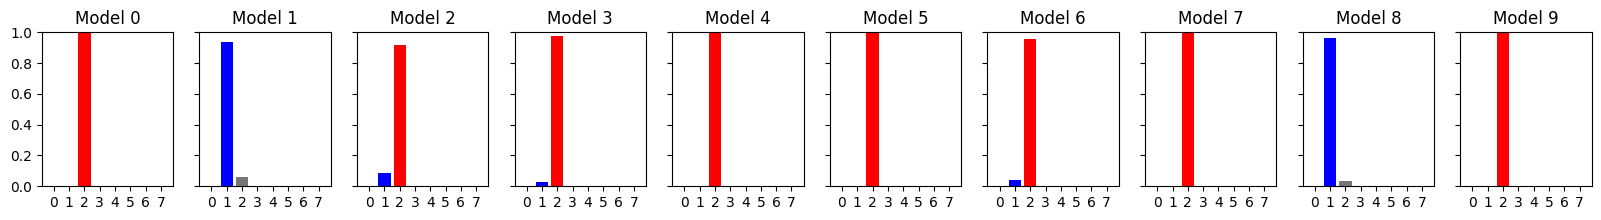

In [19]:
epsilon = 0.1
alpha = 0.01
target_class = 2

adversarial, perturbation = compute_I_FGSM_adversarial(img_tensor, 
                                                torch.tensor([target_class]).to(device), True, 
                                                models[0], 50, epsilon, alpha)

plot_adversarial(img_tensor, perturbation, adversarial)
plot_predictions(adversarial, models, 1)

## Projected Gradient Descent (PGD)  - $L_\infty$ version

In the iterative FGSM attack above, we already take multiple small FGSM-like steps and project the perturbed image back into the $L^\infty$ ball of radius $\epsilon$ around the original input after each update. This gives a stronger attack than a single FGSM step, while still enforcing the same norm constraint.

The PGD paper shows that this projected iterative attack, combined with two simple tricks, is a very strong first-order adversary:

- **Random start:** instead of starting from the clean image, initialize at a random point within the $\epsilon$-ball around the original input.  
- **Multiple restarts:** repeat the attack several times from different random starts to obtain multiple adversarial examples and increase the chance of finding a successful one.

Below we implement an $L^\infty$ PGD attack that uses the same iterative update and projection as before, but with a random start inside the $L^\infty$ ball. Multiple restarts can be obtained by calling this function several times with different seeds or initializations.

In [20]:
def compute_PGD_Linf_adversarial(image, label, targeted, model, iterations, epsilon, alpha, seed=None):

    # Optional: make the random start deterministic
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    original_image = image.detach()
    adversarial = original_image.clone().detach()

    # random start
    adversarial = adversarial + torch.empty_like(adversarial).uniform_(-epsilon, epsilon)
    adversarial = torch.clamp(adversarial, min=0, max=1)

    # similar to I-FGSM
    for i in range(iterations):

        adversarial.requires_grad = True
        output = model(adversarial)
        loss = loss_fn(output, label)
        loss.backward()

        # compute perturbation
        perturbation = alpha * adversarial.grad.data.sign()
        
        # update adversarial
        if targeted:
            adversarial = adversarial - perturbation
        else:
            adversarial = adversarial + perturbation

        # clamp update relative to the original image
        delta = torch.clamp(adversarial - original_image, -epsilon, +epsilon)
        adversarial = torch.clamp(original_image + delta, min=0, max=1).detach()

    return adversarial, delta

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1..0.1].


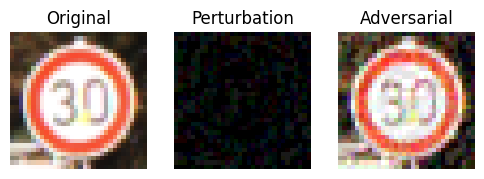

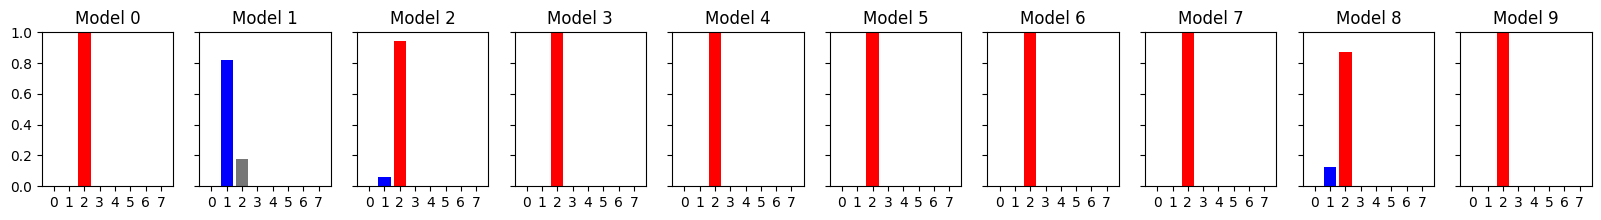

In [21]:
epsilon = 0.1
alpha = 0.01

target_class = 2

adversarial, perturbation = compute_PGD_Linf_adversarial(img_tensor, 
                                                         torch.tensor([target_class]).to(device), 
                                                         True, models[0], 200, epsilon, 0.05, seed = 42)

plot_adversarial(img_tensor, perturbation, adversarial)

plot_predictions(adversarial, models, 1)

When using multiple restarts, multiple adversarial samples are obtained. Which one should we pick?

Selecting the adversarial sample that performs best on the surrogate model (i.e., highest misclassification loss for non-targeted attacks, or lowest loss for the chosen target class in targeted attacks) is standard practice, as it maximizes attack strength on that model. However, this approach can lead to overfitting to the surrogate, potentially reducing transferability to other models.

The overfitting risk arises because the selected adversarial may exploit model-specific weaknesses that do not generalize. As a result, recent research explores strategies such as increasing output diversity by:

1.  Using ensembles of surrogate models - Ensemble attacks combine losses or gradients from multiple surrogate models during optimization to generate a single adversarial example that is adversarial for the ensemble, which empirically tends to improve transferability to unseen models. 
2. Aggregating adversarial examples (e.g., adversarial soups) to improve transferability rather than relying solely on the single "best" adversarial.

Refs addressing the overfitting risk and proposing solutions:

- Rice, L., Wong, E., & Kolter, J. Z. (2020). *Overfitting in adversarially robust deep learning* ([PDF](https://proceedings.mlr.press/v119/rice20a/rice20a.pdf))

- Wang, X., Song, C., Wang, L., & He, K. (2021). *Multi-stage Optimization based Adversarial Training*  ([PDF](https://arxiv.org/abs/2106.15357))

- Bo Yang, Hengwei Zhang, Jindong Wang, Yulong Yang, Chenhao Lin, Chao Shen, Zhengyu Zhao (2024). *Adversarial Example Soups: Improving Transferability and Robustness by Averaging Adversarial Examples.*  ([PDF](https://arxiv.org/abs/2402.18370 ))

- Yao, W., Zhang, Z., Tang, H., & Liu, Y. , *Understanding Model Ensemble in Transferable Adversarial Attack* ([PDF](https://openreview.net/forum?id=ysVDe6JGGs))



### PGD  - $L_2$ version

So far we have constrained perturbations in an $L^\infty$ ball, which limits the maximum change per pixel. The same PGD idea applies to other norms as well. In particular, we can replace the $L^\infty$ ball by an $L^2$ ball, which constrains the overall Euclidean magnitude of the perturbation instead of each individual pixel change.

The implementation below shows PGD under an $L^2$ constraint as an example of how changing the norm changes the projection step, while the rest of the attack (loss, gradient steps, targeted/untargeted variants) remains conceptually the same.

In this notebook we do not compare $L^\infty$ and $L^2$ attacks quantitatively; PGD–$L^2$ is included only to illustrate that PGD naturally extends to different norm constraints by modifying the projection operator.

In [22]:
def L2_proj(delta, epsilon):
    # Project delta onto the L2 ball of radius epsilon (for a single image)
    flat = delta.reshape(-1)
    norm = torch.norm(flat, p=2)
    if norm > epsilon:
        flat = flat * (epsilon / norm)
    return flat.view_as(delta)

In [23]:
def compute_PGD_L2_adversarial(image, label, targeted, model, iterations, epsilon, alpha, seed=None):

    # Optional: make the random start deterministic
    if seed is not None:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    original_image = image.detach()
    adversarial = original_image.clone().detach()

    # random start in L2 ball
    delta = torch.randn_like(adversarial)
    delta = L2_proj(delta, epsilon)                  # project random noise to L2 ball
    adversarial = torch.clamp(original_image + delta, min=0, max=1).detach()

    # similar to I-FGSM
    for i in range(iterations):

        adversarial.requires_grad = True
        output = model(adversarial)
        loss = loss_fn(output, label)
        loss.backward()

        # compute perturbation: L2-normalized gradient
        grad = adversarial.grad.data
        grad_flat = grad.reshape(grad.size(0), -1)
        grad_norm = torch.norm(grad_flat, p=2, dim=1, keepdim=True)
        grad_normalized = (grad_flat / (grad_norm + 1e-12)).view_as(grad)
        perturbation = alpha * grad_normalized

        # update adversarial
        if targeted:
            adversarial = adversarial - perturbation
        else:
            adversarial = adversarial + perturbation

        # clamp update relative to the original image (L2 projection + pixel clamp)
        delta = adversarial - original_image
        delta = L2_proj(delta, epsilon)
        adversarial = torch.clamp(original_image + delta, min=0, max=1).detach()

    return adversarial, delta

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23844008..0.21833615].


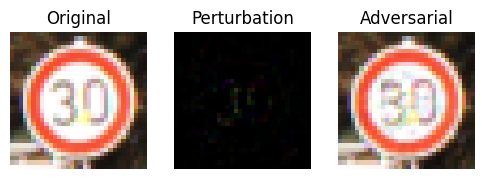

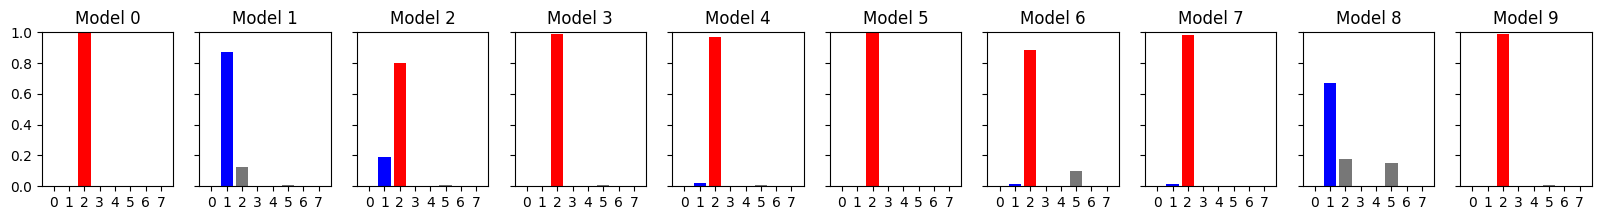

In [24]:
#converting from epsilon used in the L_inf version to the equivalent epsilon in L_2
epsilon_Linf = 0.03
epsilon = epsilon_Linf * np.sqrt(3 * 32 * 32)
alpha = epsilon / 10

target_class = 2

adversarial, perturbation = compute_PGD_L2_adversarial(img_tensor, 
                                                       torch.tensor([target_class]).to(device), 
                                                       True, models[0], 200, epsilon, alpha, seed = 42)

plot_adversarial(img_tensor, perturbation, adversarial)

plot_predictions(adversarial, models, 1)

## Attack taxonomy

Attacks can be classified according to how much information the attacker has about the target system:

- White-box attacks: The attacker has full access to the model, including parameters and gradients, and can craft adversarial samples directly on the target. As shown throughout this notebook, this setting makes it relatively easy to find high‑success perturbations.

- Gray-box attacks: In this scenario, the attacker has some information about the target system. For instance, we might know the architecture of the model, or the dataset it was trained on, or even have access to a surrogate model. No access to the model gradients or parameters.

- Black-box attacks: Under this setting, the attacker has no knowledge about the system itself. The attacker may only query the model, i.e. provide it with inputs and observe its outputs (e.g., class probabilities or labels).

What we did in this notebook:

| Setting     | Model access                        | Example in this notebook          |
|------------|--------------------------------------|-----------------------------------|
| White-box  | Full parameters + gradients          | FGSM / PGD on the training model  |
| Gray-box   | Surrogate model, same data/domain    | Attack on model 0, test on others |
| Black-box  | Only queries, no gradients           | We do not implement black‑box attacks here  |

## Evaluating adversarial generating techniques

Adversarial perturbations should ideally be compared using a perceptual metric rather than only raw attack parameters. Branco (2024) addresses this by matching attacks at two SSIM levels: $SSIM ≈ 0.95$, corresponding to almost no perceptual difference, and $SSIM ≈ 0.80$, corresponding to a larger but still recognizable degradation.

Under these matched perceptual settings on CIFAR-10, PGD is consistently more effective than FGSM. For non-targeted attacks at $SSIM ≈ 0.95$, FGSM achieves about 39–42% average transferability, while PGD reaches about 71–74%; at $SSIM ≈ 0.80$, FGSM reaches about 66–73%, while PGD reaches about 89%. The same study also found that targeted attacks were substantially harder, with targeted FGSM reaching about 13–16% transferability at $SSIM ≈ 0.95$ and about 30–31% at $SSIM ≈ 0.80$.

These results suggest that, at comparable perceptual distortion, iterative attacks such as PGD tend to be significantly stronger than one-step FGSM, while targeted attacks remain much less successful than non-targeted ones.

## Exploring transferability across architectures

Beyond controlling perceptual distortion, Branco (2024) also systematically studies transferability across architectures by crafting adversarial examples on a ResNet‑50 and evaluating them on VGG16, a shallow ConvNet, ResNet‑20, and ResNet‑110, for both CIFAR‑10 and GTSRB.[file:98] Across datasets and attack methods, the ResNet family consistently shows the highest transferability rates, while the shallow ConvNet is the most robust and VGG16 sits in between, suggesting that architectural similarity (and possibly depth) has a non‑trivial impact on how well attacks transfer between models.

## Defenses against adversarial attacks

Defenses against adversarial examples can be grouped into three broad families:

* Robust training methods. Adversarial training mixes clean and adversarial examples during training, typically by solving a min–max problem where an inner loop generates strong attacks (often PGD) and the outer loop updates the model to minimize worst‑case loss (Madry et al.,2018). This is currently the most empirically successful strategy for substantially reducing attack success, but it is computationally expensive and usually lowers clean‑data accuracy because the model optimizes for robustness rather than pure accuracy.

* Model smoothing and regularization. Techniques such as defensive distillation, label smoothing, gradient regularization, randomized smoothing, and input noise aim to make the classifier’s decision surface locally smoother so that small perturbations change the output less often (Papernot et al., 2016; Cohen et al., 2019). In practice, they can help against weaker or mismatched attacks, but many have been shown to provide limited robustness against strong, adaptive adversaries (Madry et al., 2018).

* Detection and input filtering. Another line of work focuses on detecting adversarial inputs (e.g., via auxiliary classifiers, uncertainty estimates, feature statistics) or projecting them back to a “natural” manifold using denoisers or generative models  (Tramèr et al., 2017). These methods can reduce the impact of some attacks but are hard to make reliable, since a strong attacker can often optimize specifically to evade the detector or the projection step  (Madry et al., 2018; Tramèr et al., 2017).

Overall, current best practice is to combine robust training (e.g., PGD‑based adversarial training, sometimes with ensembles) with more classical regularization and careful evaluation under strong, adaptive attacks, accepting an inherent trade‑off between robustness, clean accuracy, and computational cost (Madry et al., 2018; Tramèr et al., 2017; Branco, 2024)

## References:

* Aleksander Madry, Aleksandar Makelov, Ludwig Schmidt, Dimitris Tsipras, and Adrian Vladu. “Towards Deep Learning Models Resistant to Adversarial Attacks.” ICLR, 2018. ([PDF](https://arxiv.org/abs/1706.06083))

* Nicolas Papernot, Patrick McDaniel, Xi Wu, Somesh Jha, and Ananthram Swami. “Distillation as a Defense to Adversarial Perturbations Against Deep Neural Networks.” IEEE Symposium on Security and Privacy (S&P), 2016. (Defensive distillation) ([PDF](https://arxiv.org/abs/1511.04508))

* Wieland Brendel, Jonas Rauber, and Matthias Bethge. “Decision‑Based Adversarial Attacks: Reliable Attacks Against Black‑Box Machine Learning Models.” ICLR, 2018. ([PDF](https://arxiv.org/abs/1712.04248))

* Florian Tramèr, Alexey Kurakin, Nicolas Papernot, Ian Goodfellow, Dan Boneh, and Patrick McDaniel. “Ensemble Adversarial Training: Attacks and Defenses.”, 2017. (Adversarial training with multiple sources, transferability and robustness to black‑box attacks) ([PDF](https://arxiv.org/abs/1705.07204))

* Jeremy Cohen, Elan Rosenfeld, and J. Zico Kolter. “Certified Adversarial Robustness via Randomized Smoothing.” ICML, 2019. (Randomized smoothing as a certified defense) ([PDF](https://arxiv.org/abs/1902.02918))

* Tiago Manuel Sampaio Branco. “Exploring Adversarial Attacks and Defenses.” Master’s Dissertation, University of Minho, 2024 ([PDF](https://repositorium.uminho.pt/entities/publication/015d623f-805c-43ba-8718-944ef9671853/full)